In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from nltk.stem import PorterStemmer
from rapidfuzz import fuzz
import warnings
import os
warnings.filterwarnings('ignore')

In [ ]:
print("PyTorch version:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())

PyTorch version: 2.10.0
MPS available: True


In [ ]:
import subprocess
result = subprocess.run(['find', '/Users/Muizzdev', '-name', '*.csv', '-not', '-path', '*/.*'],
                      capture_output=True, text=True)
print(result.stdout)

/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/data/umath-validation-set-log2.csv
/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/data/umath-validation-set-arcsinh.csv
/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/data/umath-validation-set-arctanh.csv
/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/data/umath-validation-set-sin.csv
/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/data/umath-validation-set-cos.csv
/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/data/umath-validation-set-cbrt.csv
/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/data/umath-validation-set-arctan.csv
/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/data/umath-validation-set-cosh.csv
/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/dat

In [ ]:
print(os.getcwd())

/Users/Muizzdev/hackathon


# Data preparation

In [ ]:
df = pd.read_csv("/Users/Muizzdev/hackathon/hackathon_qwen.csv", encoding='utf-8-sig')


In [ ]:
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nTotal rows: {len(df)}')
print(f'Missing description: {df["description"].isna().sum()}')
print(f'Unique posters (files): {df["file"].nunique()}')
print()
print('Sample descriptions:')
for desc in df['description'].dropna().sample(15, random_state=42).values:
    print(f'  • {desc[:100]}')


Dataset shape: (144, 9)
Columns: ['file', 'venue_name', 'venue_location', 'date', 'act_name', 'performers', 'description', 'billing_notes', 'ticket_prices']

Total rows: 144
Missing description: 21
Unique posters (files): 30

Sample descriptions:
  • [No description provided]
  • After the trial.
  • Showing the Latest Novelties in Life-Motion Pictures.
  • Varietage Artistes, Vocalists and Dancers.
  • In a Marvellous and bewildering Exhibition of Human Electricity.
  • Comedians
  • A Wonderful Animal Pantomime!
  • In Their Renowned and Beautiful Negro Ballads, Glee and Madrigals. See Their Iteration of the Roller
  • A Clever Star Comedianess with a Style completely her own.
  • Passing Young Suprene Vocalist.
  • In their Drawing-room Interludes.
  • The World-Famous Musician-Athlete.
  • Serio-Comic Vocalist and Dancer.
  • Dancer and Specialty Artist.
  • In all his Wonderful New Improvisations.


In [ ]:
df['poster_id'] = df['file'].apply(
    lambda x: x.replace('NFA', '').replace('_binarized.png', '').replace('-', '.')
)
print(f'\nUnique poster IDs: {df["poster_id"].nunique()}')
print(f'Poster IDs: {sorted(df["poster_id"].unique())}')


Unique poster IDs: 30
Poster IDs: ['178R12.10', '178R12.103', '178R12.104', '178R12.16', '178R12.17', '178R12.18', '178R12.204', '178R12.205', '178R12.207', '178R12.208', '178R12.209', '178R12.211', '178R12.215', '178R12.220', '178R12.258', '178R12.259', '178R12.26', '178R12.262', '178R12.263', '178R12.267', '178R12.28', '178R12.30', '178R12.35', '178R12.37', '178R12.38', '178R12.39', '178R12.40', '178R12.41', '178R12.43', '178R12.9']


# Data Preprocessing

In [ ]:
stemmer = PorterStemmer()

In [ ]:
df_clean = df.copy()
df_clean['description'] = df_clean['description'].fillna('').str.strip()

# Treat [No description provided] and [illegible] as empty
df_clean.loc[df_clean['description'].str.lower().str.contains('no description provided', na=False), 'description'] = ''
df_clean.loc[df_clean['description'].str.lower().str.contains('illegible', na=False), 'description'] = ''

empty_mask = df_clean['description'] == ''
print(f'Rows with empty/illegible descriptions (will be labelled "Unknown"): {empty_mask.sum()}')

df_valid = df_clean[~empty_mask].copy().reset_index(drop=True)
print(f'Rows to classify: {len(df_valid)}')

Rows with empty/illegible descriptions (will be labelled "Unknown"): 38
Rows to classify: 106


In [ ]:

def clean_description(text):
    """Remove promotional/contextual noise from act descriptions."""
    text = text.replace('\n', ' ')

    noise_phrases = [
        r'for (one|six|this) week(s)? only[,.]?',
        r'(first|last|return) (appearance|engagement|six nights)[\w\s]*[,.]',
        r'engagement[\w\s]*of[\w\s]*[,.]',
        r'special engagement[\w\s]*[,.]',
        r'in (conjunction|his|her|their)[\w\s]*[,.]',
        r'will appear[\w\s]*[,.]',
        r'(mr|mrs|miss|messrs|mons|professor|prof)\.?\s+\w+',
        r'the (celebrated|renowned|popular|great|favourite|favorite)\s+',
        r'(enormous|wonderful|successful|beautiful|brilliant)\s+',
        r'return to his native[\w\s]*[,.]',
        r'"[^"]*"',
        r'\"\"[^\"]*\"\"',
    ]

    clean = text
    for pattern in noise_phrases:
        clean = re.sub(pattern, ' ', clean, flags=re.IGNORECASE)

    clean = re.sub(r'\s+', ' ', clean).strip()
    clean = clean.strip('.,;:- ')

    return clean


def preprocess(text):
    """Lowercase, remove punctuation, stem words."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [stemmer.stem(w) for w in words]
    return ' '.join(words)

In [ ]:
df_valid['desc_cleaned'] = df_valid['description'].apply(clean_description)
df_valid['desc_processed'] = df_valid['desc_cleaned'].apply(preprocess)

print('\nPreprocessing examples:')
for i in range(8):
    print(f'  RAW:       {df_valid["description"].iloc[i][:100]}')
    print(f'  CLEANED:   {df_valid["desc_cleaned"].iloc[i][:100]}')
    print(f'  PROCESSED: {df_valid["desc_processed"].iloc[i][:100]}')
    print()


Preprocessing examples:
  RAW:       The Most Wonderful Act Ever Performed by Dogs.
  CLEANED:   The Most Act Ever Performed by Dogs
  PROCESSED: the most act ever perform by dog

  RAW:       The Charming Comic-Vocalist, in all her latest Successes.
  CLEANED:   The Charming Comic-Vocalist, in all her latest Successes
  PROCESSED: the charm comic vocalist in all her latest success

  RAW:       Radio-Comedians and Humorous Actors.
  CLEANED:   Radio-Comedians and Humorous Actors
  PROCESSED: radio comedian and humor actor

  RAW:       Eccentric Comedian and Dancer.
  CLEANED:   Eccentric Comedian and Dancer
  PROCESSED: eccentr comedian and dancer

  RAW:       In a Marvellous and bewildering Exhibition of Human Electricity.
  CLEANED:   In a Marvellous and bewildering Exhibition of Human Electricity
  PROCESSED: in a marvel and bewild exhibit of human electr

  RAW:       The Premier Vaudeville Artist.
  CLEANED:   The Premier Vaudeville Artist
  PROCESSED: the premier vaudevil art

# TF IDF Vectorisation

In [ ]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=500,
    min_df=2,
    stop_words='english'
)

tfidf_matrix = tfidf.fit_transform(df_valid['desc_processed'])
feature_names = tfidf.get_feature_names_out()

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Number of features (terms): {len(feature_names)}')
print(f'\nTop 30 terms by TF-IDF sum:')
term_freq = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
top_indices = term_freq.argsort()[::-1][:30]
for idx in top_indices:
    print(f'  {feature_names[idx]:30s}  (TF-IDF sum: {term_freq[idx]:.2f})')


TF-IDF matrix shape: (106, 77)
Number of features (terms): 77

Top 30 terms by TF-IDF sum:
  comedian                        (TF-IDF sum: 9.26)
  vocalist                        (TF-IDF sum: 6.76)
  dancer                          (TF-IDF sum: 4.41)
  charact                         (TF-IDF sum: 4.33)
  comedi                          (TF-IDF sum: 4.17)
  perform                         (TF-IDF sum: 4.14)
  artist                          (TF-IDF sum: 4.10)
  comic                           (TF-IDF sum: 4.02)
  song                            (TF-IDF sum: 3.80)
  act                             (TF-IDF sum: 3.71)
  hi                              (TF-IDF sum: 3.57)
  comic vocalist                  (TF-IDF sum: 3.26)
  world                           (TF-IDF sum: 2.98)
  singer                          (TF-IDF sum: 2.89)
  vocal                           (TF-IDF sum: 2.88)
  new                             (TF-IDF sum: 2.78)
  ladi                            (TF-IDF sum: 2.61)
  danc  

# Optimal Number of K

Finding optimal number of K using elbow and silhouette

In [ ]:
K_range = range(3, 16)
inertias = []
silhouette_scores_list = []

In [ ]:
for k in K_range:
    km = KMeans(n_clusters=k, random_state=1234, n_init=10)
    labels = km.fit_predict(tfidf_matrix)
    inertias.append(km.inertia_)
    sil = silhouette_score(tfidf_matrix, labels)
    silhouette_scores_list.append(sil)
    print(f'K={k:2d}')
    print(f'Inertia: {km.inertia_:.1f}')
    print(f'Silhouette: {sil:.4f}')

K= 3
Inertia: 206.0
Silhouette: 0.0949
K= 4
Inertia: 197.1
Silhouette: 0.1107
K= 5
Inertia: 191.8
Silhouette: 0.1243
K= 6
Inertia: 186.9
Silhouette: 0.1238
K= 7
Inertia: 182.0
Silhouette: 0.1319
K= 8
Inertia: 175.3
Silhouette: 0.1442
K= 9
Inertia: 169.4
Silhouette: 0.1586
K=10
Inertia: 168.3
Silhouette: 0.1625
K=11
Inertia: 160.3
Silhouette: 0.1744
K=12
Inertia: 156.9
Silhouette: 0.1780
K=13
Inertia: 154.0
Silhouette: 0.1863
K=14
Inertia: 153.9
Silhouette: 0.1890
K=15
Inertia: 148.3
Silhouette: 0.2189


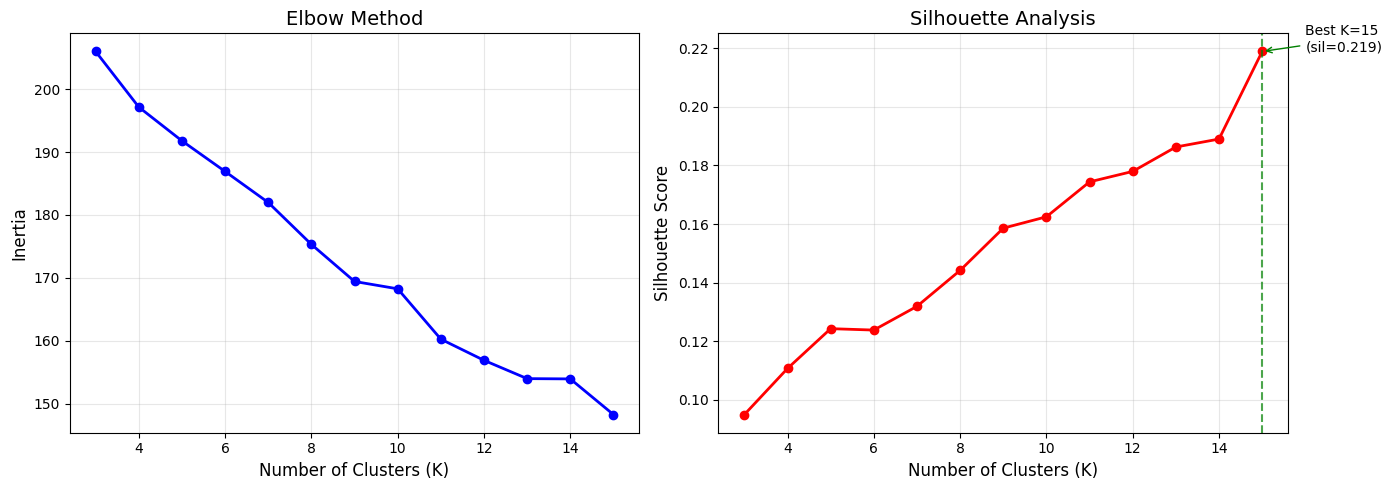

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14)
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouette_scores_list, 'ro-', linewidth=2)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Analysis', fontsize=14)
ax2.grid(True, alpha=0.3)

best_k = list(K_range)[np.argmax(silhouette_scores_list)]
best_sil = max(silhouette_scores_list)
ax2.axvline(x=best_k, color='green', linestyle='--', alpha=0.7)
ax2.annotate(f'Best K={best_k}\n(sil={best_sil:.3f})',
             xy=(best_k, best_sil), fontsize=10,
             xytext=(best_k+1, best_sil),
             arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(f'Best K by silhouette score: {best_k}')

Best K by silhouette score: 15


The silhouette score keeps increasing because of the nature of the data, not because K=15 is meaningful. With only ~260 short text descriptions, as you increase K, each cluster becomes smaller and more homogeneous by default, even randomly assigned groups would score higher with more clusters. A silhouette score of 0.20 is still poor, meaning even at K=15 the clusters aren't well-separated.

The elbow method is actually more appropriate here. Looking at the inertia plot, the rate of decrease slows noticeably around K=7-8. Before that, each new cluster captures a lot of new structure. After that, you're getting diminishing returns, each new cluster is just splitting an existing group rather than finding a genuinely new one.

# K-Means Clustering (SKIP)

In [ ]:
k = 10


kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
df_valid['cluster'] = kmeans.fit_predict(tfidf_matrix)

print(f'Silhouette score: {silhouette_score(tfidf_matrix, df_valid["cluster"]):.4f}')
print(f'\nCluster distribution:')
print(df_valid['cluster'].value_counts().sort_index())

Silhouette score: 0.1670

Cluster distribution:
cluster
0    10
1    45
2    24
3    80
4    11
5    37
6    10
7    12
8     8
9    23
Name: count, dtype: int64


In [ ]:
# Inspect each cluster
print('\n' + '=' * 80)
for cluster_id in range(k):
    centroid = kmeans.cluster_centers_[cluster_id]
    top_term_indices = centroid.argsort()[::-1][:10]
    top_terms = [feature_names[i] for i in top_term_indices]
    cluster_acts = df_valid[df_valid['cluster'] == cluster_id]['act_name_en'].values

    print(f'\nCLUSTER {cluster_id}  ({len(cluster_acts)} acts)')
    print(f'  Top terms: {", ".join(top_terms)}')
    print(f'  Sample acts:')
    for act in cluster_acts[:8]:
        print(f'    • {act}')
    print('-' * 80)



CLUSTER 0  (10 acts)
  Top terms: actress, burlesqu, burlesqu actress, vocalist, burlesqu artist, actress vocalist, vocalist burlesqu, dancer, artist, vocalist dancer
  Sample acts:
    • Burlesque Actress
    • Burlesque Actress, Vocalist and Dancer
    • Charming Burlesque Actress
    • Serio-Comic Vocalist and Burlesque Actress
    • Serio-Comedienne and Burlesque Actress
    • Burlesque Actress, Vocalist and Skirt Dancer
    • Protean Actress
    • Burlesque Artistes, Vocalists and Dancers
--------------------------------------------------------------------------------

CLUSTER 1  (45 acts)
  Top terms: vocalist, comic, vocalist dancer, comic vocalist, dancer, serio, serio comic, descript, descript vocalist, extempor
  Sample acts:
    • The Phenomenal Young Violinist and Vocalist
    • Vocalist
    • Soprano Vocalist
    • Comic Vocalist
    • Soprano Vocalist
    • Comic Vocalist and Dancer
    • Vocalists and Dancers
    • Soprano Vocalist
-------------------------------------

# Visualising clusters (pca 2d) (SKIP)

Explained variance: 13.9%


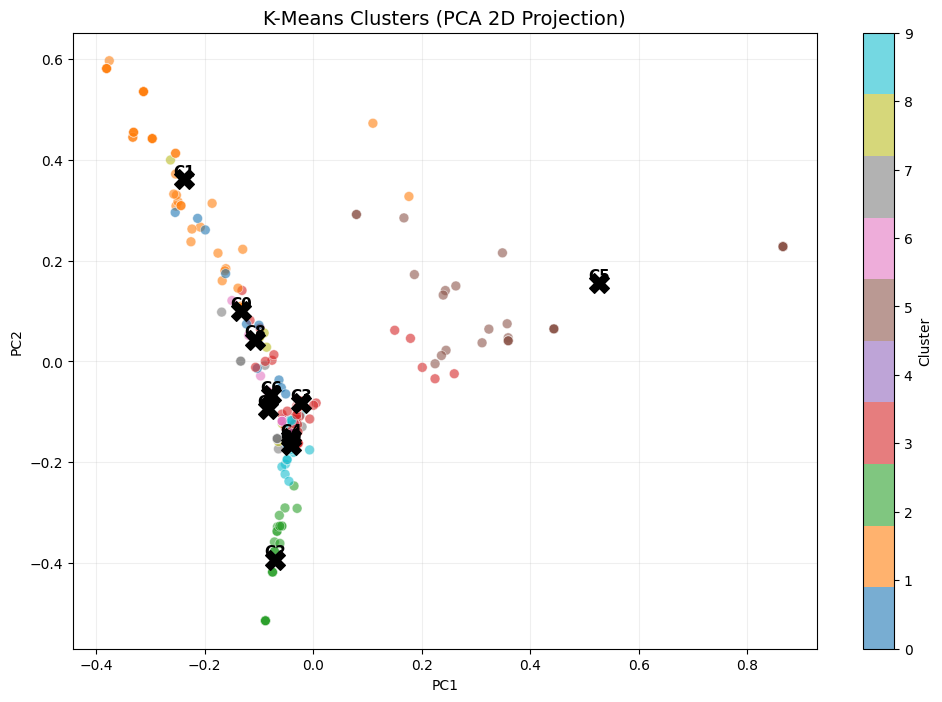

In [ ]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())

print(f'Explained variance: {pca.explained_variance_ratio_.sum():.1%}')

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    coords[:, 0], coords[:, 1],
    c=df_valid['cluster'],
    cmap='tab10',
    alpha=0.6, s=50,
    edgecolors='white', linewidth=0.5
)

centroids_2d = pca.transform(kmeans.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_2d):
    ax.scatter(cx, cy, c='black', marker='X', s=200, zorder=5)
    ax.annotate(f'C{i}', (cx, cy), fontsize=11, fontweight='bold',
                ha='center', va='bottom', color='black')

plt.colorbar(scatter, label='Cluster')
ax.set_title('K-Means Clusters (PCA 2D Projection)', fontsize=14)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(True, alpha=0.2)
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# Hierarchical Clustering (SKIP)

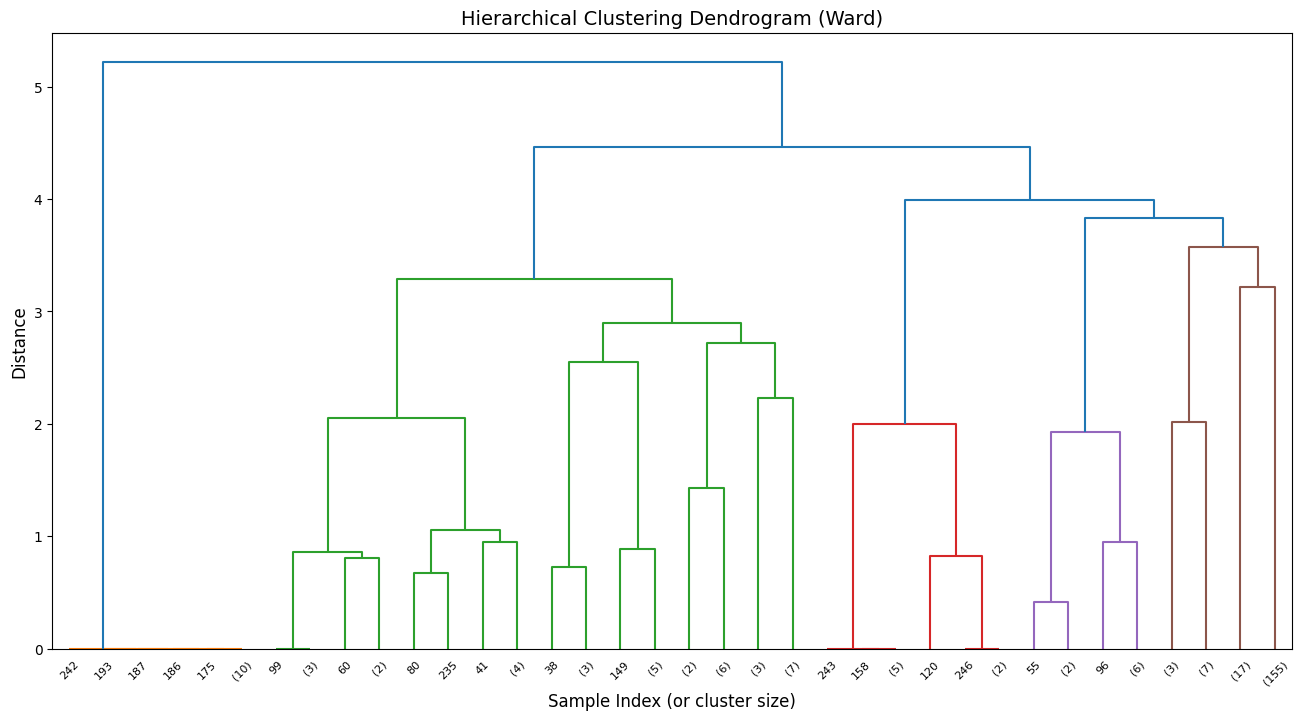

In [ ]:
linkage_matrix = linkage(tfidf_matrix.toarray(), method='ward')

fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(
    linkage_matrix,
    truncate_mode='level',
    p=5,
    ax=ax,
    leaf_font_size=8
)
ax.set_title('Hierarchical Clustering Dendrogram (Ward)', fontsize=14)
ax.set_xlabel('Sample Index (or cluster size)', fontsize=12)
ax.set_ylabel('Distance', fontsize=12)
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

Comparing silhouette scores

In [ ]:
# Compare silhouette scores
agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
df_valid['cluster_hierarchical'] = agg.fit_predict(tfidf_matrix.toarray())

sil_kmeans = silhouette_score(tfidf_matrix, df_valid['cluster'])
sil_hier = silhouette_score(tfidf_matrix, df_valid['cluster_hierarchical'])

print(f'Silhouette Scores (K={k}):')
print(f'  K-Means:       {sil_kmeans:.4f}')
print(f'  Hierarchical:  {sil_hier:.4f}')
print(f'\n>>> Better method: {"K-Means" if sil_kmeans >= sil_hier else "Hierarchical"}')

Silhouette Scores (K=10):
  K-Means:       0.1670
  Hierarchical:  0.1722

>>> Better method: Hierarchical


#  Cosine Similarity Classification (USE THIS)

Defining categories

In [ ]:
categories = {
    'Comedians': 'comedian comedienne comic burlesque slapstick knockabout funny clown serio-comic comical absurdist humourist low comedy',
    'Singing': 'vocalist singer soprano ballad vocal songster songstress warbler chorus hymn operatic tenor baritone serio alto songs',
    'Dance': 'dancer dancing danseuse ballet skirt dancer boot dancer choreography',
    'Musicians': 'pianist harpist banjo concertina violinist instrumentalist musical instrument fiddle cellist organ soloist',
    'Jugglers': 'juggler juggling',
    'Acrobats': 'acrobat equilibrist tumbler contortionist horizontal bar athletic trapeze',
    'Gymnasts': 'gymnast gymnastics horizontal bar',
    'Tightrope walking': 'tightrope walking wire rope',
    'Magic': 'conjurer wizard magician illusionist necromancer second sight transformation quick change telepathy',
    'Motion pictures': 'bioscope motion pictures moving pictures film animated stereoscopic life motion cinematograph screening',
    'Animal trainers': 'animal dog cockatoo performing animals trained',
    'Male impersonators': 'impersonator male impersonator',
    'Stunt performers': 'cycling bicycle novelty stunt cyclist rocket',
    'Imitation': 'mimic imitator delineator impersonation character studies',
}

cat_names = list(categories.keys())

Boosting First Term Importance

In [ ]:
def boost_first_term(text):
    """Repeat the first word to give it more TF-IDF weight."""
    words = text.split()
    if words:
        return words[0] + ' ' + words[0] + ' ' + text
    return text


df_valid['desc_boosted'] = df_valid['desc_processed'].apply(boost_first_term)

Cosine Similarity for MultiLabel Class

In [ ]:
all_texts = list(df_valid['desc_boosted']) + [preprocess(desc) for desc in categories.values()]

tfidf_sim = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=500,
    stop_words='english'
)
tfidf_all = tfidf_sim.fit_transform(all_texts)

act_vectors = tfidf_all[:len(df_valid)]
cat_vectors = tfidf_all[len(df_valid):]

sim_matrix = cosine_similarity(act_vectors, cat_vectors)

# Assign top 2 categories above threshold
MULTI_THRESHOLD = 0.05

df_valid['primary_category'] = [cat_names[i] for i in sim_matrix.argmax(axis=1)]
df_valid['primary_confidence'] = sim_matrix.max(axis=1)


def get_top_labels(row_idx, max_labels=2):
    scores = sim_matrix[row_idx]
    sorted_idx = scores.argsort()[::-1]
    labels = []
    for j in sorted_idx:
        if scores[j] >= MULTI_THRESHOLD and len(labels) < max_labels:
            labels.append(cat_names[j])
    return labels


df_valid['all_categories'] = [
    ', '.join(get_top_labels(i)) for i in range(len(df_valid))
]

df_valid['num_labels'] = df_valid['all_categories'].apply(lambda x: len(x.split(', ')) if x else 0)
df_valid['needs_fuzzy'] = df_valid['all_categories'] == ''

print('Cosine Similarity (Multi-Label)')
print(f'Acts with at least 1 cosine label: {(~df_valid["needs_fuzzy"]).sum()}')
print(f'Acts needing fuzzy fallback:        {df_valid["needs_fuzzy"].sum()}')
print(f'\nLabel count distribution:')
print(df_valid['num_labels'].value_counts().sort_index())



Cosine Similarity (Multi-Label)
Acts with at least 1 cosine label: 60
Acts needing fuzzy fallback:        46

Label count distribution:
num_labels
0    46
1    45
2    15
Name: count, dtype: int64


Fuzzy matching (as a fallback)

In [ ]:
category_keywords = {}
for cat, desc in categories.items():
    category_keywords[cat] = desc.split()


def fuzzy_classify(act_name):
    """Match act description against each category's keywords using fuzzy matching."""
    act_lower = act_name.lower()
    results = {}

    for cat, keywords in category_keywords.items():
        best_score = 0
        for keyword in keywords:
            score = fuzz.partial_ratio(keyword, act_lower)
            if score > best_score:
                best_score = score
        results[cat] = best_score

    return results


In [ ]:
FUZZY_THRESHOLD = 60

fuzzy_mask = df_valid['needs_fuzzy']
print(f'Fuzzy Matching on {fuzzy_mask.sum()} acts')

for idx in df_valid[fuzzy_mask].index:
    scores = fuzzy_classify(df_valid.at[idx, 'desc_cleaned'])

    sorted_cats = sorted(scores.items(), key=lambda x: -x[1])
    matched_cats = [cat for cat, score in sorted_cats if score >= FUZZY_THRESHOLD][:2]

    if matched_cats:
        df_valid.at[idx, 'all_categories'] = ', '.join(matched_cats)
        df_valid.at[idx, 'primary_category'] = matched_cats[0]
        df_valid.at[idx, 'num_labels'] = len(matched_cats)
    else:
        best_cat = max(scores, key=scores.get)
        df_valid.at[idx, 'all_categories'] = best_cat
        df_valid.at[idx, 'primary_category'] = best_cat
        df_valid.at[idx, 'num_labels'] = 1

Fuzzy Matching on 46 acts


Results Summary

In [ ]:
print(f'\nTotal acts classified: {len(df_valid)}')
print(f'Acts with multiple labels: {(df_valid["num_labels"] > 1).sum()} ({(df_valid["num_labels"] > 1).mean():.1%})')
print(f'Acts with single label: {(df_valid["num_labels"] == 1).sum()}')
print(f'Average labels per act: {df_valid["num_labels"].mean():.2f}')

print(f'\nPrimary category distribution:')
print(df_valid['primary_category'].value_counts())

all_cat_counts = {}
for cats in df_valid['all_categories']:
    for cat in cats.split(', '):
        cat = cat.strip()
        all_cat_counts[cat] = all_cat_counts.get(cat, 0) + 1

print(f'\nTotal label appearances (including multi-labels):')
for cat, count in sorted(all_cat_counts.items(), key=lambda x: -x[1]):
    primary_count = (df_valid['primary_category'] == cat).sum()
    secondary_count = count - primary_count
    print(f'  {cat:25s}  primary: {primary_count:3d},  secondary: {secondary_count:3d},  total: {count:3d}')


Total acts classified: 106
Acts with multiple labels: 59 (55.7%)
Acts with single label: 47
Average labels per act: 1.56

Primary category distribution:
primary_category
Comedians             33
Singing               17
Dance                 12
Musicians             11
Imitation              7
Acrobats               6
Motion pictures        6
Animal trainers        5
Magic                  3
Jugglers               2
Male impersonators     2
Stunt performers       1
Tightrope walking      1
Name: count, dtype: int64

Total label appearances (including multi-labels):
  Comedians                  primary:  33,  secondary:   5,  total:  38
  Singing                    primary:  17,  secondary:  15,  total:  32
  Dance                      primary:  12,  secondary:   6,  total:  18
  Musicians                  primary:  11,  secondary:   6,  total:  17
  Imitation                  primary:   7,  secondary:   5,  total:  12
  Acrobats                   primary:   6,  secondary:   6,  total:

Classifications Samples

In [ ]:
print('MULTI-LABEL EXAMPLES\n')

multi = df_valid[df_valid['num_labels'] > 1].sort_values('num_labels', ascending=False)
print(f'Acts with multiple labels ({len(multi)} total):\n')
for _, row in multi.head(25).iterrows():
    print(f'  [{row["num_labels"]} labels] {row["desc_cleaned"][:80]}')
    print(f'           → {row["all_categories"]}')
    print()

print('\n=== SINGLE-LABEL EXAMPLES ===\n')
single = df_valid[df_valid['num_labels'] == 1]
for cat in sorted(single['primary_category'].unique()):
    acts = single[single['primary_category'] == cat]
    print(f'{cat} ({len(acts)} single-label acts):')
    for _, row in acts.head(3).iterrows():
        print(f'  • {row["desc_cleaned"][:80]}')
    print()



MULTI-LABEL EXAMPLES

Acts with multiple labels (59 total):

  [2 labels] Radio-Comedians and Humorous Actors
           → Comedians, Singing

  [2 labels] Jumping Nonsense
           → Dance, Jugglers

  [2 labels] A Animal Pantomime!
           → Animal trainers, Motion pictures

  [2 labels] A Clever American Vocal and Instrumental Act
           → Musicians, Singing

  [2 labels] The Simple One
           → Male impersonators, Comedians

  [2 labels] And his Harp
           → Musicians, Acrobats

  [2 labels] In a Novel Vagabond Comedy Scene
           → Comedians, Stunt performers

  [2 labels] Entertainer, with His Voice and Piano
           → Musicians, Animal trainers

  [2 labels] Famer in Definitive Character Comedy
           → Comedians, Imitation

  [2 labels] Twins of Connaught
           → Magic, Comedians

  [2 labels] and his Black Friend
           → Acrobats, Gymnasts

  [2 labels] Popular Comedian. Boy and Drill
           → Comedians, Acrobats

  [2 labels] Prince 

# Similarity Heatmap

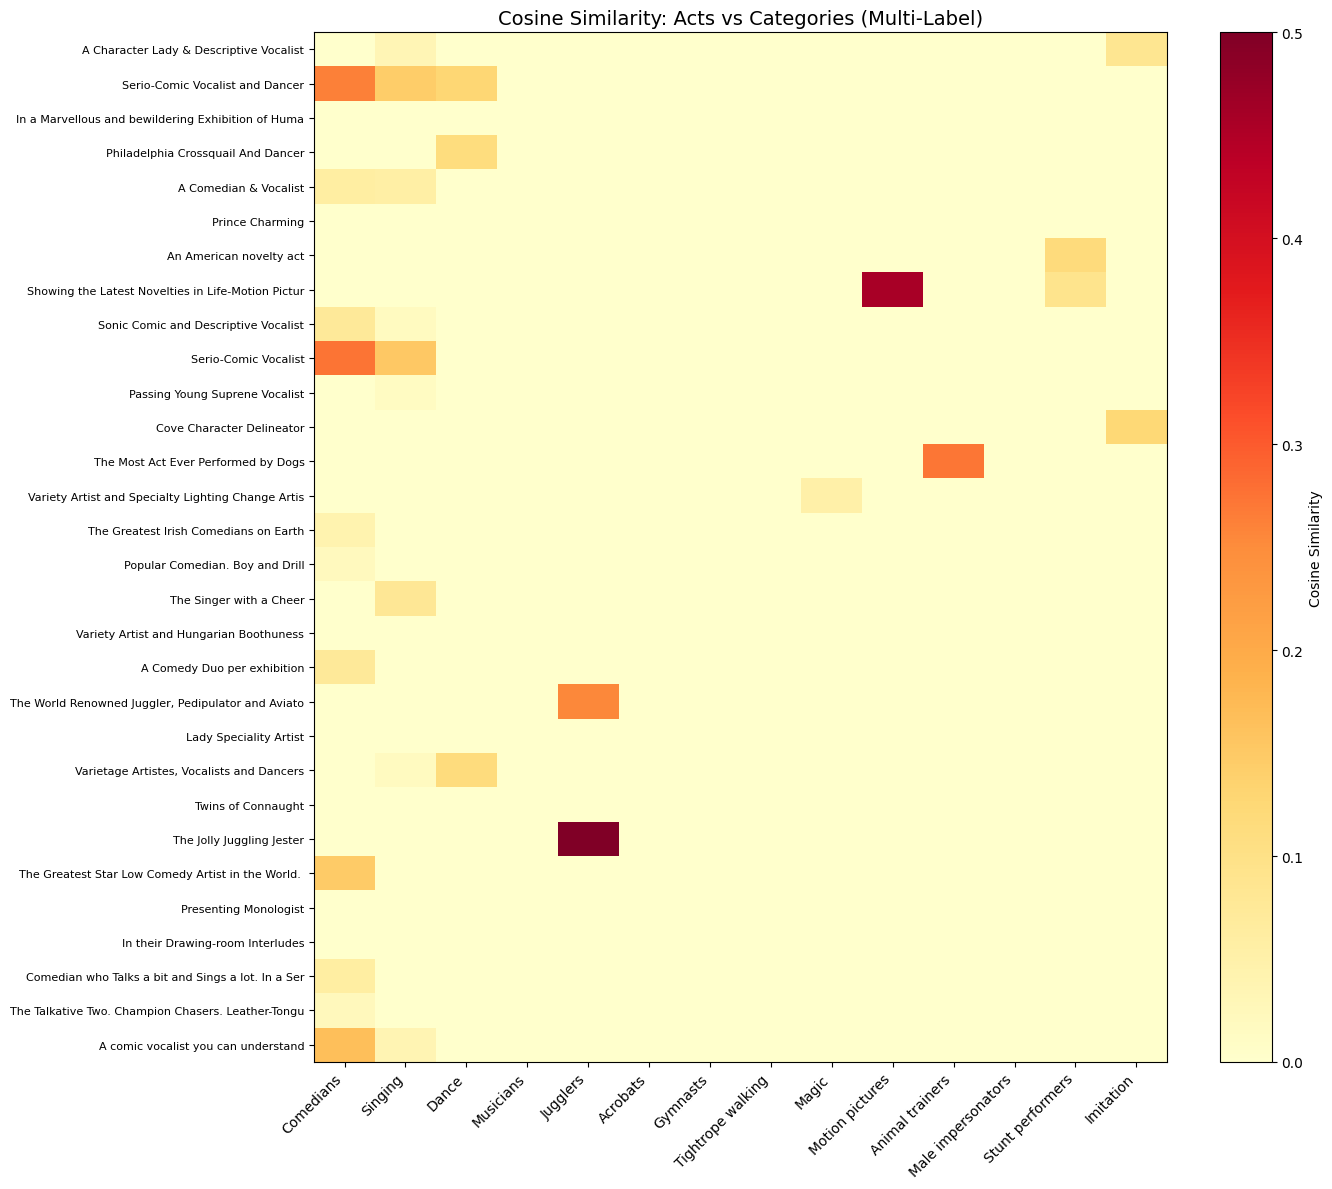

In [ ]:
sample_size = min(30, len(df_valid))
sample_idx = df_valid.sample(sample_size, random_state=42).index
sample_sim = sim_matrix[sample_idx]
sample_labels = df_valid.loc[sample_idx, 'desc_cleaned'].values

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sample_sim, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(cat_names)))
ax.set_xticklabels(cat_names, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(sample_labels)))
ax.set_yticklabels([s[:50] for s in sample_labels], fontsize=8)
ax.set_title('Cosine Similarity: Acts vs Categories (Multi-Label)', fontsize=14)
plt.colorbar(im, label='Cosine Similarity')
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


# Multi Label Distribution Chart

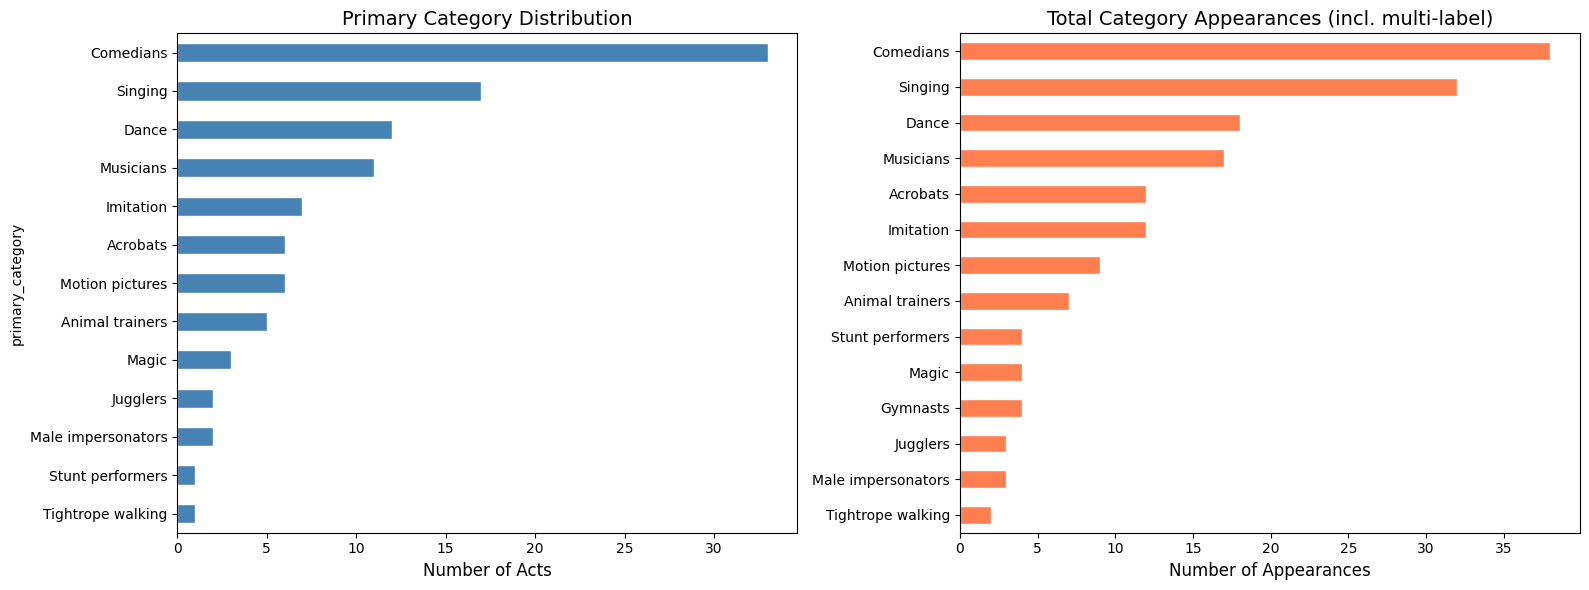

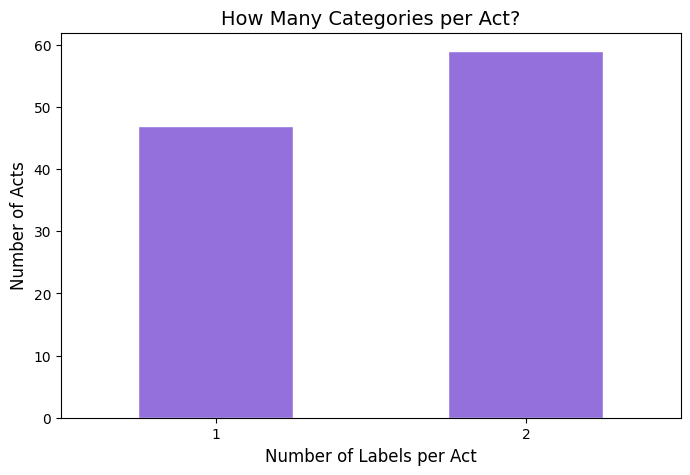

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

df_valid['primary_category'].value_counts().plot(
    kind='barh', ax=ax1, color='steelblue', edgecolor='white'
)
ax1.set_xlabel('Number of Acts', fontsize=12)
ax1.set_title('Primary Category Distribution', fontsize=14)
ax1.invert_yaxis()

cat_series = pd.Series(all_cat_counts).sort_values(ascending=True)
cat_series.plot(kind='barh', ax=ax2, color='coral', edgecolor='white')
ax2.set_xlabel('Number of Appearances', fontsize=12)
ax2.set_title('Total Category Appearances (incl. multi-label)', fontsize=14)

plt.tight_layout()
plt.savefig('category_distribution_multilabel.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
df_valid['num_labels'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color='mediumpurple', edgecolor='white'
)
ax.set_xlabel('Number of Labels per Act', fontsize=12)
ax.set_ylabel('Number of Acts', fontsize=12)
ax.set_title('How Many Categories per Act?', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.savefig('label_count_histogram.png', dpi=150, bbox_inches='tight')
plt.show()


# Export Results

In [ ]:
df_output = df.copy()
df_output['primary_category'] = 'Unknown'
df_output['all_categories'] = 'Unknown'
df_output['num_labels'] = 0

valid_indices = df_clean[~empty_mask].index
for i, orig_idx in enumerate(valid_indices):
    df_output.at[orig_idx, 'primary_category'] = df_valid.at[i, 'primary_category']
    df_output.at[orig_idx, 'all_categories'] = df_valid.at[i, 'all_categories']
    df_output.at[orig_idx, 'num_labels'] = df_valid.at[i, 'num_labels']

output_path = 'hackathon_qwen_classified.csv'
df_output.to_csv(output_path, index=False)
print(f'Saved to {output_path}')
print(f'\nFinal distribution (primary):')
print(df_output['primary_category'].value_counts())
print(f'\nTotal: {len(df_output)}')

print('\nSample rows:')
cols = ['act_name', 'description', 'primary_category', 'all_categories', 'num_labels']
print(df_output[cols].sample(20, random_state=42).to_string())



Saved to hackathon_qwen_classified.csv

Final distribution (primary):
primary_category
Unknown               38
Comedians             33
Singing               17
Dance                 12
Musicians             11
Imitation              7
Acrobats               6
Motion pictures        6
Animal trainers        5
Magic                  3
Jugglers               2
Male impersonators     2
Stunt performers       1
Tightrope walking      1
Name: count, dtype: int64

Total: 144

Sample rows:
                                                 act_name                                                                                                           description    primary_category                    all_categories  num_labels
117                                           COMBINATION  In their Side-epithets Absurdity, entitled 'A GREAT MISTAKE!'. Another Christie Performer, for Six Nights only. Miss           Comedians                  Comedians, Magic           2
19                         

# Validation against library metadata

data read and category mapping

In [ ]:
library_df = pd.read_csv('library_metadata.csv', encoding='utf-8-sig')

print(f'Library metadata: {len(library_df)} posters')
print(f'Your classifications: {len(df_output)} acts')

library_to_ours = {
    'Comedians': 'Comedians',
    'Singing': 'Singing',
    'Dance': 'Dance',
    'Musicians': 'Musicians',
    'Jugglers': 'Jugglers',
    'Acrobats': 'Acrobats',
    'Gymnasts': 'Gymnasts',
    'Tightrope walking': 'Tightrope walking',
    'Magic': 'Magic',
    'Motion pictures': 'Motion pictures',
    'Animal trainers': 'Animal trainers',
    'Male impersonators': 'Male impersonators',
    'Imitation': 'Imitation',
    'Stunt performers': 'Stunt performers',
}



Library metadata: 30 posters
Your classifications: 144 acts


mapping file to library accesion number

In [ ]:
df_output['poster_id'] = df_output['file'].apply(
    lambda x: x.replace('NFA', '').replace('_binarized.png', '').replace('-', '.')
)

results = []

for _, poster in library_df.iterrows():
    accession = poster['Accession Number']

    raw_subjects = str(poster['Subject']).split(';')
    library_labels = set()
    for s in raw_subjects:
        s = s.strip().rstrip(';').strip()
        if s and s in library_to_ours:
            library_labels.add(library_to_ours[s])

    poster_acts = df_output[df_output['poster_id'] == accession]

    if len(poster_acts) == 0:
        continue

    predicted_labels = set()
    for cats in poster_acts['all_categories']:
        if isinstance(cats, str) and cats != 'Unknown':
            for cat in cats.split(', '):
                predicted_labels.add(cat.strip())

    results.append({
        'accession': accession,
        'library_labels': library_labels,
        'predicted_labels': predicted_labels,
        'num_acts': len(poster_acts),
    })

print(f'Posters matched for validation: {len(results)} / {len(library_df)}')

Posters matched for validation: 30 / 30


Per category metrics

In [ ]:
all_categories_val = sorted(set(
    list(library_to_ours.values()) +
    [cat for r in results for cat in r['predicted_labels']]
))

tp = {cat: 0 for cat in all_categories_val}
fp = {cat: 0 for cat in all_categories_val}
fn = {cat: 0 for cat in all_categories_val}

for r in results:
    for cat in all_categories_val:
        in_library = cat in r['library_labels']
        in_predicted = cat in r['predicted_labels']

        if in_library and in_predicted:
            tp[cat] += 1
        elif in_predicted and not in_library:
            fp[cat] += 1
        elif in_library and not in_predicted:
            fn[cat] += 1


per category validation

In [ ]:
print(f'{"Category":25s}  {"F1":>10s}  {"Precision":>10s}  {"Recall":>10s}  {"TP":>4s}  {"FP":>4s}  {"FN":>4s}')
print('-' * 85)

f1_scores = {}
for cat in all_categories_val:
    precision = tp[cat] / (tp[cat] + fp[cat]) if (tp[cat] + fp[cat]) > 0 else 0
    recall = tp[cat] / (tp[cat] + fn[cat]) if (tp[cat] + fn[cat]) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    f1_scores[cat] = f1

for cat in sorted(f1_scores, key=f1_scores.get, reverse=True):
    precision = tp[cat] / (tp[cat] + fp[cat]) if (tp[cat] + fp[cat]) > 0 else 0
    recall = tp[cat] / (tp[cat] + fn[cat]) if (tp[cat] + fn[cat]) > 0 else 0
    print(f'{cat:25s}  {f1_scores[cat]:10.2%}  {precision:10.2%}  {recall:10.2%}  {tp[cat]:4d}  {fp[cat]:4d}  {fn[cat]:4d}')



Category                           F1   Precision      Recall    TP    FP    FN
-------------------------------------------------------------------------------------
Singing                        85.11%     100.00%      74.07%    20     0     7
Comedians                      82.35%     100.00%      70.00%    21     0     9
Jugglers                       66.67%      66.67%      66.67%     2     1     1
Motion pictures                66.67%      75.00%      60.00%     6     2     4
Dance                          62.86%      78.57%      52.38%    11     3    10
Animal trainers                54.55%      42.86%      75.00%     3     4     1
Musicians                      44.44%      37.50%      54.55%     6    10     5
Acrobats                       14.29%       9.09%      33.33%     1    10     2
Gymnasts                        0.00%       0.00%       0.00%     0     4     1
Imitation                       0.00%       0.00%       0.00%     0     9     1
Magic                           0.

Overall results

In [ ]:
# Weighted-averaged
total_support = sum(tp[cat] + fn[cat] for cat in all_categories_val)
weighted_f1 = sum(
    f1_scores[cat] * (tp[cat] + fn[cat]) / total_support
    for cat in all_categories_val
    if (tp[cat] + fn[cat]) > 0
)
weighted_precision = sum(
    (tp[cat] / (tp[cat] + fp[cat]) if (tp[cat] + fp[cat]) > 0 else 0) * (tp[cat] + fn[cat]) / total_support
    for cat in all_categories_val
    if (tp[cat] + fn[cat]) > 0
)
weighted_recall = sum(
    (tp[cat] / (tp[cat] + fn[cat]) if (tp[cat] + fn[cat]) > 0 else 0) * (tp[cat] + fn[cat]) / total_support
    for cat in all_categories_val
    if (tp[cat] + fn[cat]) > 0
)

print(f'{"OVERALL (weighted-avg)":25s}  {weighted_f1:10.2%}  {weighted_precision:10.2%}  {weighted_recall:10.2%}')

OVERALL (weighted-avg)         65.86%      76.16%      59.83%


poster level comparison

In [ ]:
for r in results:
    match = r['library_labels'] == r['predicted_labels']
    overlap = r['library_labels'] & r['predicted_labels']
    missed = r['library_labels'] - r['predicted_labels']
    extra = r['predicted_labels'] - r['library_labels']

    status = 'EXACT MATCH' if match else 'PARTIAL' if overlap else 'MISMATCH'

    print(f'{r["accession"]} ({r["num_acts"]} acts) — {status}')
    print(f'  Library:   {", ".join(sorted(r["library_labels"])) or "none"}')
    print(f'  Predicted: {", ".join(sorted(r["predicted_labels"])) or "none"}')
    if missed:
        print(f'  MISSED:    {", ".join(sorted(missed))}')
    if extra:
        print(f'  EXTRA:     {", ".join(sorted(extra))}')
    print()

178R12.9 (3 acts) — PARTIAL
  Library:   Comedians, Dance, Singing, Stunt performers
  Predicted: Acrobats, Dance, Singing, Tightrope walking
  MISSED:    Comedians, Stunt performers
  EXTRA:     Acrobats, Tightrope walking

178R12.10 (4 acts) — PARTIAL
  Library:   Comedians, Dance, Singing
  Predicted: Comedians, Dance, Imitation, Musicians, Singing
  EXTRA:     Imitation, Musicians

178R12.16 (8 acts) — MISMATCH
  Library:   Animal trainers, Comedians, Dance, Gymnasts, Singing
  Predicted: none
  MISSED:    Animal trainers, Comedians, Dance, Gymnasts, Singing

178R12.17 (2 acts) — PARTIAL
  Library:   Comedians, Dance, Singing
  Predicted: Acrobats, Motion pictures, Singing
  MISSED:    Comedians, Dance
  EXTRA:     Acrobats, Motion pictures

178R12.18 (5 acts) — PARTIAL
  Library:   Comedians, Musicians, Singing
  Predicted: Acrobats, Comedians, Dance, Singing
  MISSED:    Musicians
  EXTRA:     Acrobats, Dance

178R12.26 (3 acts) — PARTIAL
  Library:   Comedians, Dance, Singing
  

Validation chart

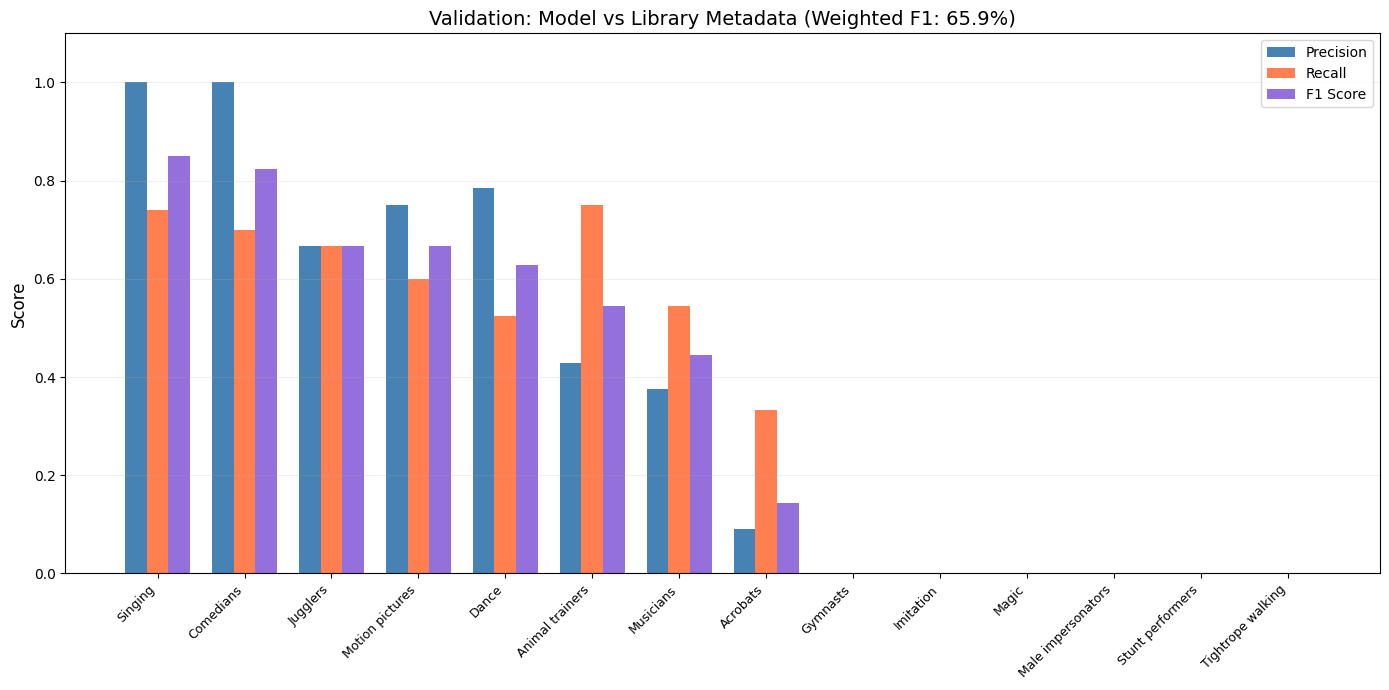

Weighted F1 Score: 65.9%


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
cats = [c for c in f1_scores.keys() if (tp[c] + fp[c] + fn[c]) > 0]
cats_sorted = sorted(cats, key=lambda c: f1_scores[c], reverse=True)
f1_vals = [f1_scores[c] for c in cats_sorted]
prec_vals = [tp[c] / (tp[c] + fp[c]) if (tp[c] + fp[c]) > 0 else 0 for c in cats_sorted]
rec_vals = [tp[c] / (tp[c] + fn[c]) if (tp[c] + fn[c]) > 0 else 0 for c in cats_sorted]

x = np.arange(len(cats_sorted))
width = 0.25

ax.bar(x - width, prec_vals, width, label='Precision', color='steelblue')
ax.bar(x, rec_vals, width, label='Recall', color='coral')
ax.bar(x + width, f1_vals, width, label='F1 Score', color='mediumpurple')

ax.set_xticks(x)
ax.set_xticklabels(cats_sorted, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Validation: Model vs Library Metadata (Weighted F1: {weighted_f1:.1%})', fontsize=14)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('validation_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Weighted F1 Score: {weighted_f1:.1%}')